#2. Raccolta e Pre-processing dei dati

In [435]:
import yfinance as yf
import datetime
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,\
                            confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


###Scaricare il dataset da Yahoo Finance

In [436]:
msft = yf.download("MSFT", period="max", actions=True)

msft.to_csv("MSFT.csv")

/tmp/ipykernel_670/1013757848.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download("MSFT", period="max", actions=True)
[*********************100%***********************]  1 of 1 completed


###Utilizziamo la copia del dataset ed apportiamo le modifiche necessarie al fine di ottenere le colonne di interesse con valori correttamente formattati

In [437]:
file = "/content/MSFT.csv"

df_clean = pd.read_csv(file)
df = df_clean.copy()
df = df.rename(columns={"Price" : "Date"})
df = df.drop([0,1], axis=0)
df = df.drop(["Stock Splits",'Dividends'], axis=1)
df["Date"] = pd.to_datetime(df["Date"])
columns = ['Close', 'High', 'Low', 'Open','Volume']
df[columns] = df[columns].astype(float)
df = df.reset_index(drop=True)
df.head()



,Date,Close,High,Low,Open,Volume
0,1986-03-13,0.059125,0.061765,0.053847,0.053847,1.031789e+09
1,1986-03-14,0.061237,0.062293,0.059125,0.059125,3.081600e+08
2,1986-03-17,0.062293,0.062821,0.061237,0.061237,1.331712e+08
3,1986-03-18,0.060709,0.062821,0.060181,0.062293,6.776640e+07
4,1986-03-19,0.059653,0.061237,0.059125,0.060709,4.789440e+07


###Verifichiamo le caratteristiche del dataset ed assicuriamoci che non vi siano valori mancanti

In [438]:
df.shape

(10177, 6)

In [439]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10177 entries, 0 to 10176
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10177 non-null  datetime64[ns]
 1   Close   10177 non-null  float64       
 2   High    10177 non-null  float64       
 3   Low     10177 non-null  float64       
 4   Open    10177 non-null  float64       
 5   Volume  10177 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 477.2 KB


In [440]:
df.isna().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [441]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,10177,10177.000000,10177.000000,10177.000000,10177.000000,1.017700e+04
mean,2006-05-14 20:33:16.501916160,71.083659,71.772330,70.343045,71.071696,5.527333e+07
min,1986-03-13 00:00:00,0.054902,0.055958,0.053847,0.053847,2.304000e+06
25%,1996-04-03 00:00:00,3.943456,3.986218,3.881695,3.952960,3.024000e+07
50%,2006-05-12 00:00:00,19.568422,19.764804,19.329404,19.527627,4.841170e+07
75%,2016-06-21 00:00:00,48.491245,48.781935,47.953788,48.372215,6.920640e+07
max,2026-08-05 00:00:00,538.658508,551.048411,537.366702,550.830123,1.031789e+09
std,NaN,120.770064,121.867085,119.585039,120.764242,3.790013e+07


#3. Feature Engineering

### Calcolo dei rendimenti giornalieri

In [442]:
#definiamo una funzione che ci permette di calcolare i rendimenti percentuali giornalieri
#e aggiungerli ad una copia del dataframe originario passando due parametri:
#1: il dataframe orginario
#2: il nome della colonna in cui sono presenti i prezzi di chiusura
#3: il nome della colonna che andremo a creare

#NOTA: se il dataframe ha già subito le opportune modifiche, tale funzione può
#essere estesa per calcolare diversi rendimenti periodali (es. settimanali, mensili, ecc.).
#Questo giustifica il 3° argomento della funzione

def dfrend(dataframe,p_close,name_rend):

  df_re = dataframe.copy()
  df_re[name_rend] = (df_re[p_close] / df[p_close].shift(1) - 1) * 100
  df_re = df_re.drop(0, axis=0)

  return df_re

In [443]:
df_r = dfrend(df,"Close","Rend. GG %")
df_r

,Date,Close,High,Low,Open,Volume,Rend. GG %
1,1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000.0,3.571264
2,1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200.0,1.725025
3,1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400.0,-2.543145
4,1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400.0,-1.739061
5,1986-03-20,0.058070,0.059653,0.057542,0.059653,58435200.0,-2.654737
...,...,...,...,...,...,...,...
10172,2026-07-30,451.100006,458.690002,432.440002,437.899994,110160700.0,15.506733
10173,2026-07-31,464.720001,466.839996,449.329987,450.000000,60846000.0,3.019285
10174,2026-08-03,487.649994,491.649994,475.000000,476.130005,66762100.0,4.934152
10175,2026-08-04,492.809998,499.440002,479.170013,480.899994,50455500.0,1.058137


### Calcolo delle medie temporali e volatilità

In [444]:
df_r['MA5']=df_r["Close"].rolling(window=5).mean()
df_r['MA10']=df_r["Close"].rolling(window=10).mean()
df_r['MA20']=df_r["Close"].rolling(window=20).mean()

In [445]:
df_r["volatility20"]=df_r['Rend. GG %'].rolling(window=20).std()*np.sqrt(252)

### Inclusione di lag features

In [446]:
df_r["Rend. GG t-1"]=df_r["Rend. GG %"].shift(1)
df_r["Rend. GG t-2"]=df_r["Rend. GG %"].shift(2)
df_r["Rend. GG t-3"]=df_r["Rend. GG %"].shift(3)

col = ["Rend. GG t-1","Rend. GG t-2","Rend. GG t-3"]
df_r[col] = df_r[col].fillna(0)
df_r

,Date,Close,High,Low,Open,Volume,Rend. GG %,MA5,MA10,MA20,volatility20,Rend. GG t-1,Rend. GG t-2,Rend. GG t-3
1,1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000.0,3.571264,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
2,1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200.0,1.725025,NaN,NaN,NaN,NaN,3.571264,0.000000,0.000000
3,1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400.0,-2.543145,NaN,NaN,NaN,NaN,1.725025,3.571264,0.000000
4,1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400.0,-1.739061,NaN,NaN,NaN,NaN,-2.543145,1.725025,3.571264
5,1986-03-20,0.058070,0.059653,0.057542,0.059653,58435200.0,-2.654737,0.060392,NaN,NaN,NaN,-1.739061,-2.543145,1.725025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10172,2026-07-30,451.100006,458.690002,432.440002,437.899994,110160700.0,15.506733,401.158008,397.157004,393.154500,59.720599,-0.714376,1.092264,1.938694
10173,2026-07-31,464.720001,466.839996,449.329987,450.000000,60846000.0,3.019285,417.762006,404.247003,396.866000,60.160149,15.506733,-0.714376,1.092264
10174,2026-08-03,487.649994,491.649994,475.000000,476.130005,66762100.0,4.934152,437.472003,412.783002,401.911501,61.321639,3.019285,15.506733,-0.714376
10175,2026-08-04,492.809998,499.440002,479.170013,480.899994,50455500.0,1.058137,457.364001,422.289001,407.110001,61.272130,4.934152,3.019285,15.506733


### Definizione della colonna target

In [447]:
#Definisci la variabile target come 1 se il prezzo chiuderà più alto il giorno successivo, 0 altrimenti.

df_r["Target"] = (df_r["Close"] < df_r["Close"].shift(-1)).astype(int)
df_r

,Date,Close,High,Low,Open,Volume,Rend. GG %,MA5,MA10,MA20,volatility20,Rend. GG t-1,Rend. GG t-2,Rend. GG t-3,Target
1,1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000.0,3.571264,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1
2,1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200.0,1.725025,NaN,NaN,NaN,NaN,3.571264,0.000000,0.000000,0
3,1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400.0,-2.543145,NaN,NaN,NaN,NaN,1.725025,3.571264,0.000000,0
4,1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400.0,-1.739061,NaN,NaN,NaN,NaN,-2.543145,1.725025,3.571264,0
5,1986-03-20,0.058070,0.059653,0.057542,0.059653,58435200.0,-2.654737,0.060392,NaN,NaN,NaN,-1.739061,-2.543145,1.725025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10172,2026-07-30,451.100006,458.690002,432.440002,437.899994,110160700.0,15.506733,401.158008,397.157004,393.154500,59.720599,-0.714376,1.092264,1.938694,1
10173,2026-07-31,464.720001,466.839996,449.329987,450.000000,60846000.0,3.019285,417.762006,404.247003,396.866000,60.160149,15.506733,-0.714376,1.092264,1
10174,2026-08-03,487.649994,491.649994,475.000000,476.130005,66762100.0,4.934152,437.472003,412.783002,401.911501,61.321639,3.019285,15.506733,-0.714376,1
10175,2026-08-04,492.809998,499.440002,479.170013,480.899994,50455500.0,1.058137,457.364001,422.289001,407.110001,61.272130,4.934152,3.019285,15.506733,0


In [448]:
corr = df_r.corr()
corr

,Date,Close,High,Low,Open,Volume,Rend. GG %,MA5,MA10,MA20,volatility20,Rend. GG t-1,Rend. GG t-2,Rend. GG t-3,Target
Date,1.000000,0.727889,0.728010,0.727720,0.727813,-0.426953,-0.020094,0.727929,0.727888,0.727720,-0.346146,-0.019992,-0.020061,-0.020444,0.025161
Close,0.727889,1.000000,0.999949,0.999951,0.999886,-0.375748,-0.003291,0.999773,0.999489,0.998966,-0.167073,-0.003565,-0.003694,-0.004519,0.017876
High,0.728010,0.999949,1.000000,0.999933,0.999948,-0.374900,-0.006071,0.999821,0.999562,0.999076,-0.165859,-0.003636,-0.003931,-0.004704,0.018056
Low,0.727720,0.999951,0.999933,1.000000,0.999947,-0.376483,-0.006008,0.999805,0.999515,0.998968,-0.168345,-0.003232,-0.003550,-0.004489,0.018020
Open,0.727813,0.999886,0.999948,0.999947,1.000000,-0.375649,-0.008622,0.999842,0.999583,0.999078,-0.167193,-0.003400,-0.003745,-0.004703,0.018141
Volume,-0.426953,-0.375748,-0.374900,-0.376483,-0.375649,1.000000,-0.002925,-0.375875,-0.375440,-0.375136,0.361955,-0.020906,-0.027305,-0.016258,-0.007895
Rend. GG %,-0.020094,-0.003291,-0.006071,-0.006008,-0.008622,-0.002925,1.000000,-0.010066,-0.010770,-0.011020,0.011748,-0.015586,-0.037492,-0.027590,-0.021090
MA5,0.727929,0.999773,0.999821,0.999805,0.999842,-0.375875,-0.010066,1.000000,0.999856,0.999403,-0.167302,-0.008253,-0.006746,-0.005993,0.017914
MA10,0.727888,0.999489,0.999562,0.999515,0.999583,-0.375440,-0.010770,0.999856,1.000000,0.999746,-0.167084,-0.009961,-0.009393,-0.009278,0.018104
MA20,0.727720,0.998966,0.999076,0.998968,0.999078,-0.375136,-0.011020,0.999403,0.999746,1.000000,-0.165435,-0.010528,-0.010346,-0.010649,0.018249


<Axes: >

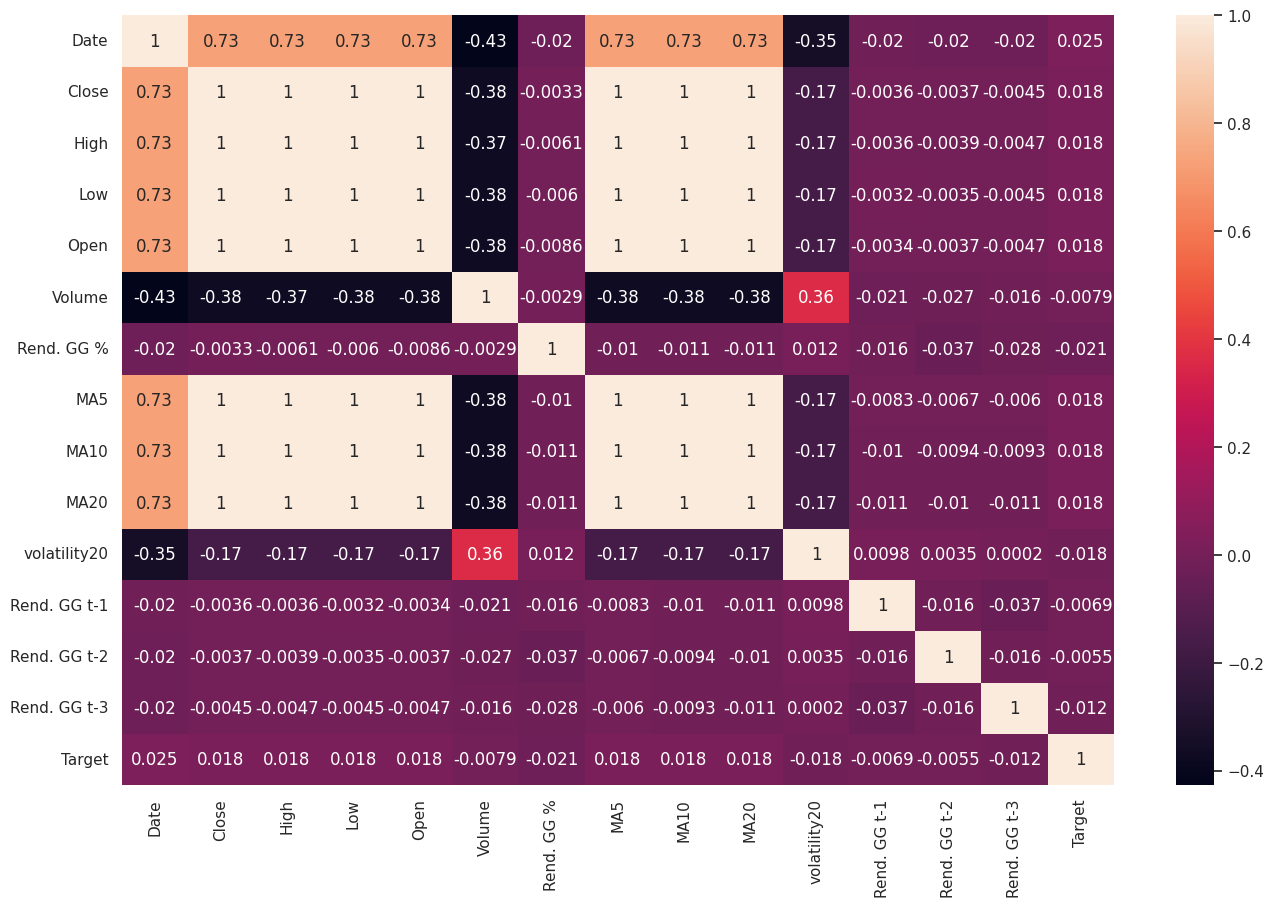

In [449]:
plt.figure(figsize=(16, 10))
sns.heatmap(corr, annot=True)

#4. Suddivisione del set, addestramento e calcolo delle metriche

Ridefiniamo il dataset per creare il dataset per le futures e quello della variabile target

In [450]:
df_r = df_r.dropna()
df_r = df_r.reset_index(drop=True)
df_r

,Date,Close,High,Low,Open,Volume,Rend. GG %,MA5,MA10,MA20,volatility20,Rend. GG t-1,Rend. GG t-2,Rend. GG t-3,Target
0,1986-04-11,0.060709,0.061765,0.060181,0.060181,17222400.0,1.769839,0.059020,0.058597,0.058571,31.917415,0.892849,1.818054,0.917350,1
1,1986-04-14,0.061237,0.061765,0.060709,0.060709,12153600.0,0.869484,0.059759,0.058914,0.058571,29.421176,1.769839,0.892849,1.818054,0
2,1986-04-15,0.061237,0.061237,0.059125,0.061237,9302400.0,0.000000,0.060392,0.059284,0.058518,28.721322,0.869484,1.769839,0.892849,1
3,1986-04-16,0.063349,0.063877,0.060709,0.061237,31910400.0,3.449047,0.061237,0.059812,0.058650,29.735602,0.000000,0.869484,1.769839,1
4,1986-04-17,0.063877,0.063877,0.063349,0.063349,22003200.0,0.833315,0.062082,0.060340,0.058861,28.865889,3.449047,0.000000,0.869484,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10152,2026-07-30,451.100006,458.690002,432.440002,437.899994,110160700.0,15.506733,401.158008,397.157004,393.154500,59.720599,-0.714376,1.092264,1.938694,1
10153,2026-07-31,464.720001,466.839996,449.329987,450.000000,60846000.0,3.019285,417.762006,404.247003,396.866000,60.160149,15.506733,-0.714376,1.092264,1
10154,2026-08-03,487.649994,491.649994,475.000000,476.130005,66762100.0,4.934152,437.472003,412.783002,401.911501,61.321639,3.019285,15.506733,-0.714376,1
10155,2026-08-04,492.809998,499.440002,479.170013,480.899994,50455500.0,1.058137,457.364001,422.289001,407.110001,61.272130,4.934152,3.019285,15.506733,0


Testiamo un modello senza applicare la regolarizzazione

In [451]:
#Definiamo le feature (X) e il target (Y) per l'intero dataset
X = df_r[["MA20", "volatility20", "Rend. GG %","Rend. GG t-1","Rend. GG t-2","Rend. GG t-3"]]
Y = df_r["Target"]

#NOTA: Osservando la matrice di correlazione precedente selezioniamo solo MA20 in quanto presenta una maggiore correlazione
#      con le altre feutures incluse nel modello ed al fine di eliminare a priori la perfetta collinearità tra MA20 e MA5 e MA10 (corr=1)

# Inizializziamo TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=20)

#NOTA: la scelta di n_split=20 non è casuale, sono state valutati anche i valori
#       5 e 10 e quella scelta e quella che fornisce i risultati migliori

train_score=[]
test_score=[]

#Ottieniamo gli indici per l'ultimo split train-test, quindi
#Iteriamo attraverso tutti gli split e manteniamo l'ultimo.
for train_index, test_index in tscv.split(X, Y):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    lr = LogisticRegression()
    lr.fit(X_train, Y_train)

    y_predict_train = lr.predict(X_train)
    y_proba_train = lr.predict_proba(X_train)[:,1]

    y_predict_test = lr.predict(X_test)
    y_proba_test = lr.predict_proba(X_test)[:,1]

    logloss_train = log_loss(Y_train, y_proba_train)
    accuracy_train = accuracy_score(Y_train, y_predict_train)
    precision_train = precision_score(Y_train, y_predict_train)
    recall_train = recall_score(Y_train, y_predict_train)
    f1_train = f1_score(Y_train, y_predict_train)
    auc_train = roc_auc_score(Y_train, y_proba_train)

    logloss_test = log_loss(Y_test, y_proba_test)
    accuracy_test = accuracy_score(Y_test, y_predict_test)
    precision_test = precision_score(Y_test, y_predict_test)
    recall_test = recall_score(Y_test, y_predict_test)
    f1_test = f1_score(Y_test, y_predict_test)
    auc_test = roc_auc_score(Y_test, y_proba_test)

    train_score.append((logloss_train, accuracy_train, precision_train, recall_train, f1_train,auc_train))
    test_score.append((logloss_test, accuracy_test, precision_test, recall_test, f1_test, auc_test))

scores = {"Risultati della predizione su set di addestramento" : np.array(train_score),
          "Risultati della predizione su set di test" : np.array(test_score),}

train_result = pd.DataFrame(train_score, columns=["Log Loss", "Accuracy", "Precision", "Recall", "F1", "Roc Auc"])
test_result = pd.DataFrame(test_score, columns=["Log Loss", "Accuracy", "Precision", "Recall", "F1", "Roc Auc"])

print(f"Metriche del train set: \n{train_result.mean()} \n \nMetriche del test set: \n{test_result.mean()}")

Metriche del train set: 
Log Loss     0.692225
Accuracy     0.518518
Precision    0.517492
Recall       0.485480
F1           0.495761
Roc Auc      0.522902
dtype: float64 
 
Metriche del test set: 
Log Loss     0.697512
Accuracy     0.500725
Precision    0.496570
Recall       0.454832
F1           0.349327
Roc Auc      0.504329
dtype: float64


Testiamo il modello applicando la regolarizzazione l2

In [452]:
X = df_r[["MA20", "volatility20", "Rend. GG %","Rend. GG t-1","Rend. GG t-2","Rend. GG t-3"]]
Y = df_r["Target"]

tscv = TimeSeriesSplit(n_splits=20)

train_score=[]
test_score=[]

for train_index, test_index in tscv.split(X, Y):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    lr = LogisticRegression(penalty="l2", C=100)
    lr.fit(X_train, Y_train)

    y_predict_train = lr.predict(X_train)
    y_proba_train = lr.predict_proba(X_train)[:,1]

    y_predict_test = lr.predict(X_test)
    y_proba_test = lr.predict_proba(X_test)[:,1]

    logloss_train = log_loss(Y_train, y_proba_train)
    accuracy_train = accuracy_score(Y_train, y_predict_train)
    precision_train = precision_score(Y_train, y_predict_train)
    recall_train = recall_score(Y_train, y_predict_train)
    f1_train = f1_score(Y_train, y_predict_train)
    auc_train = roc_auc_score(Y_train, y_proba_train)

    logloss_test = log_loss(Y_test, y_proba_test)
    accuracy_test = accuracy_score(Y_test, y_predict_test)
    precision_test = precision_score(Y_test, y_predict_test)
    recall_test = recall_score(Y_test, y_predict_test)
    f1_test = f1_score(Y_test, y_predict_test)
    auc_test = roc_auc_score(Y_test, y_proba_test)

    train_score.append((logloss_train, accuracy_train, precision_train, recall_train, f1_train,auc_train))
    test_score.append((logloss_test, accuracy_test, precision_test, recall_test, f1_test, auc_test))

scores = {"Risultati della predizione su set di addestramento" : np.array(train_score),
          "Risultati della predizione su set di test" : np.array(test_score),}

train_result = pd.DataFrame(train_score, columns=["Log Loss", "Accuracy", "Precision", "Recall", "F1", "Roc Auc"])
test_result = pd.DataFrame(test_score, columns=["Log Loss", "Accuracy", "Precision", "Recall", "F1", "Roc Auc"])

print(f"Metriche del train set: \n{train_result.mean()} \n \nMetriche del test set: \n{test_result.mean()}")

Metriche del train set: 
Log Loss     0.692225
Accuracy     0.518404
Precision    0.517351
Recall       0.485469
F1           0.495695
Roc Auc      0.522895
dtype: float64 
 
Metriche del test set: 
Log Loss     0.697534
Accuracy     0.500725
Precision    0.496570
Recall       0.454832
F1           0.349327
Roc Auc      0.504332
dtype: float64


Testiamo il modello applicando la regolarizzazione l1

In [453]:
X = df_r[["MA20", "volatility20", "Rend. GG %","Rend. GG t-1","Rend. GG t-2","Rend. GG t-3"]]
Y = df_r["Target"]

tscv = TimeSeriesSplit(n_splits=20)

train_score=[]
test_score=[]

for train_index, test_index in tscv.split(X, Y):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    lr = LogisticRegression(penalty="l1", C=100, solver = "saga")
    lr.fit(X_train, Y_train)

    y_proba_train = lr.predict_proba(X_train)[:,1]
    y_predict_train = (y_proba_train>=0.4).astype(int)

    y_proba_test = lr.predict_proba(X_test)[:,1]
    y_predict_test = (y_proba_test>=0.4).astype(int)

    logloss_train = log_loss(Y_train, y_proba_train)
    accuracy_train = accuracy_score(Y_train, y_predict_train)
    precision_train = precision_score(Y_train, y_predict_train)
    recall_train = recall_score(Y_train, y_predict_train)
    f1_train = f1_score(Y_train, y_predict_train)
    auc_train = roc_auc_score(Y_train, y_proba_train)

    logloss_test = log_loss(Y_test, y_proba_test)
    accuracy_test = accuracy_score(Y_test, y_predict_test)
    precision_test = precision_score(Y_test, y_predict_test)
    recall_test = recall_score(Y_test, y_predict_test)
    f1_test = f1_score(Y_test, y_predict_test)
    auc_test = roc_auc_score(Y_test, y_proba_test)

    train_score.append((logloss_train, accuracy_train, precision_train, recall_train, f1_train,auc_train))
    test_score.append((logloss_test, accuracy_test, precision_test, recall_test, f1_test, auc_test))

scores = {"Risultati della predizione su set di addestramento" : np.array(train_score),
          "Risultati della predizione su set di test" : np.array(test_score),}

train_result = pd.DataFrame(train_score, columns=["Log Loss", "Accuracy", "Precision", "Recall", "F1", "Roc Auc"])
test_result = pd.DataFrame(test_score, columns=["Log Loss", "Accuracy", "Precision", "Recall", "F1", "Roc Auc"])

print(f"Metriche su train set: \n{train_result.mean()} \n \nMetriche su test set: \n{test_result.mean()}")

Metriche su train set: 
Log Loss     0.692225
Accuracy     0.498047
Precision    0.498192
Recall       0.998328
F1           0.664677
Roc Auc      0.522894
dtype: float64 
 
Metriche su test set: 
Log Loss     0.697534
Accuracy     0.507453
Precision    0.507553
Recall       0.996071
F1           0.671923
Roc Auc      0.504428
dtype: float64


Scegliamo l'ultimo modello in quanto presenta delle metriche migliori. In particolare Recall e F1

#5 e 6 . Modello di Machine Learning e Valutazione delle performance

Definiamo una funzione che ci permetta di valutare il nostro modello

In [454]:
def evaluate_model (model, dataset, threshold):
  X, y = dataset

  y_probability = model.predict_proba(X)[:,1]
  y_pred = (y_probability>=threshold).astype(int)

  print(f"Log Loss: {log_loss(y , y_probability):.3f}")
  print(f"Accuracy: {accuracy_score(y , y_pred):.3f}")
  print(f"Precision: {precision_score(y , y_pred):.3f}")
  print(f"Recall: {recall_score(y , y_pred):.3f}")
  print(f"f1_score: {f1_score(y , y_pred):.3f}")
  print(f"ROC_AUC: {roc_auc_score(y , y_probability):.3f}")

Riaddestriamo il modello sul dataset finale

In [455]:
lr = LogisticRegression(penalty="l2", C=100)

lr.fit(X_train, Y_train)

LogisticRegression(C=100)

Valutiamo il modello calcolando le metriche

In [456]:
evaluate_model (lr, (X_train, Y_train), 0.4)

Log Loss: 0.692
Accuracy: 0.506
Precision: 0.506
Recall: 0.999
f1_score: 0.672
ROC_AUC: 0.521


In [457]:
evaluate_model(lr,(X_test, Y_test),0.4)

Log Loss: 0.695
Accuracy: 0.520
Precision: 0.520
Recall: 1.000
f1_score: 0.684
ROC_AUC: 0.512


Analizziamo i coefficienti

In [458]:
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0],
})

coeff.sort_values("Coefficient")

,Feature,Coefficient
2,Rend. GG %,-0.046520
1,volatility20,-0.029638
3,Rend. GG t-1,-0.023022
5,Rend. GG t-3,-0.021648
4,Rend. GG t-2,-0.015062
0,MA20,0.036768


Visualizziamo la matrice di confusione

In [459]:
def plot_confusion_matrix (y_true, y_pred):

  cm = confusion_matrix(y_true, y_pred)

  df_cm = pd.DataFrame(cm,
                       index = ["Negative", "Positive"],
                       columns = ["Predicted Negative", "Predicted Positive"])

  sns.heatmap(df_cm, annot=True, fmt='d')

In [460]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

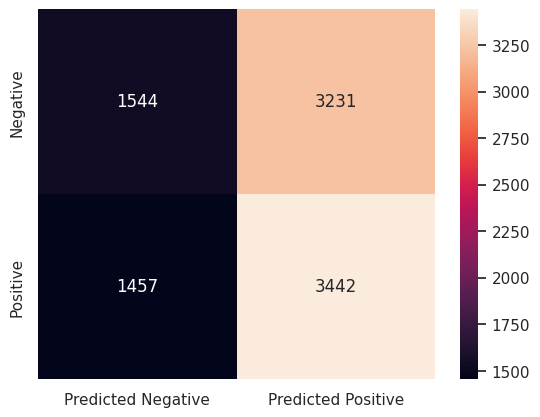

In [461]:
plot_confusion_matrix(Y_train, y_pred_train)

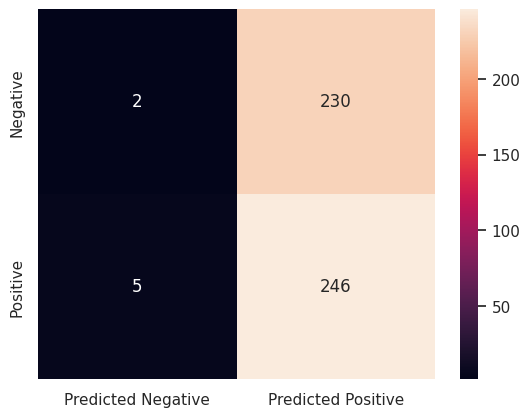

In [462]:
plot_confusion_matrix(Y_test, y_pred_test)

Costruiamo la Learning Curve

<function matplotlib.pyplot.show(close=None, block=None)>

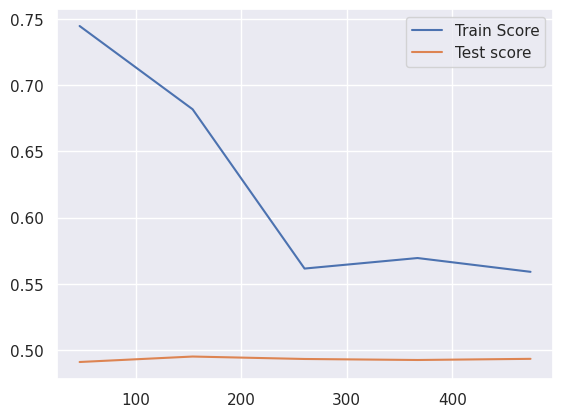

In [463]:
sns.set_theme()
train_sizes_abs, train_sc, test_sc = learning_curve(lr, X_train, Y_train, cv=tscv)

plt.plot(train_sizes_abs, train_sc.mean(axis=1), label = "Train Score")
plt.plot(train_sizes_abs, test_sc.mean(axis=1), label = "Test score")
plt.legend()
plt.show

#7. Gestione del rischio

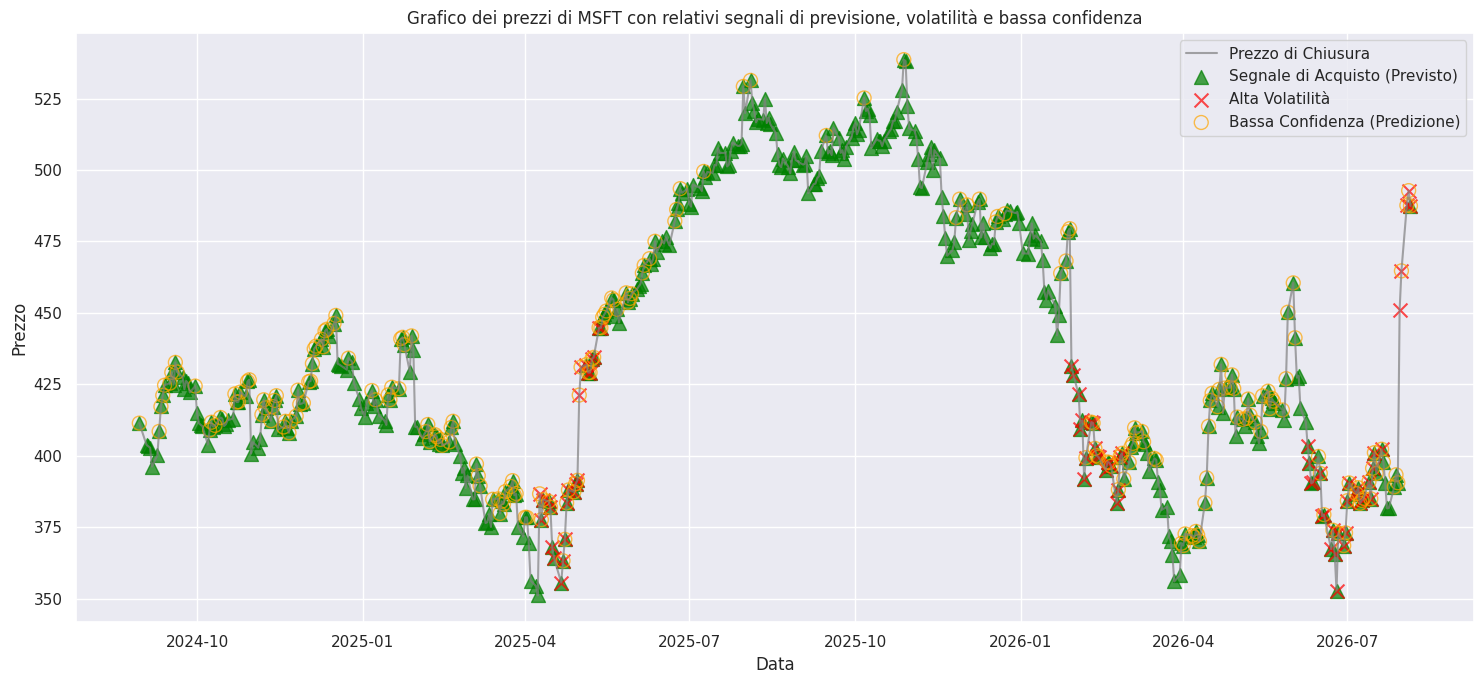


--- Riepilogo di Statistiche e Condizioni di Rischio e Confidenza (Test Set) ---
Numero di giorni con Alta Volatilità: 75
Numero di previsioni con Bassa Confidenza: 224
Soglia di Volatilità utilizzata (75° percentile): 36.61
Range di probabilità per Bassa Confidenza: (0.45 - 0.55)


In [464]:
# Ricostruiamo il DataFrame del set di test con le feature originali e le date
# Usiamo l'ultimo `test_index` disponibile dal loop di TimeSeriesSplit
df_test_visual = df_r.iloc[test_index].copy()

# Aggiungiamo le probabilità e le predizioni del modello al DataFrame
# Nota: y_proba_test e y_pred_test sono stati calcolati sull'X_test scalato.
df_test_visual['Predicted_Probability'] = y_proba_test
df_test_visual['Predicted_Signal'] = y_pred_test

# Definiamo una soglia per l'alta volatilità (sopra il 75° percentile della volatilità storica del dataset completo)
volatility_threshold = df_r['volatility20'].quantile(0.75)
df_test_visual['High_Volatility'] = df_test_visual['volatility20'] > volatility_threshold

# Definiamo un segnale di 'bassa confidenza: se la probabilità è vicina al 50% (tra 0.45 e 0.55)
low_confidence_threshold_upper = 0.55
low_confidence_threshold_lower = 0.45
df_test_visual['Low_Confidence'] = (df_test_visual['Predicted_Probability'] < low_confidence_threshold_upper) & \
                                   (df_test_visual['Predicted_Probability'] > low_confidence_threshold_lower)

# Costruiamo un grafico contenente i vari segnali
plt.figure(figsize=(15, 7))

# Plot prezzo di chiusura
plt.plot(df_test_visual['Date'], df_test_visual['Close'], label='Prezzo di Chiusura', color='gray', alpha=0.7)

# Plot segnali di acquisto/aumento (Target = 1)
buy_signals = df_test_visual[df_test_visual['Predicted_Signal'] == 1]
plt.scatter(buy_signals['Date'], buy_signals['Close'], marker='^', color='green', s=100, label='Segnale di Acquisto (Previsto)', alpha=0.7)

# Plot periodi di alta volatilità
high_volatility_periods = df_test_visual[df_test_visual['High_Volatility']]
plt.scatter(high_volatility_periods['Date'], high_volatility_periods['Close'], marker='x', color='red', s=100, label='Alta Volatilità', alpha=0.7)

# Plot punti di bassa confidenza
low_confidence_points = df_test_visual[df_test_visual['Low_Confidence']]
plt.scatter(low_confidence_points['Date'], low_confidence_points['Close'], marker='o', facecolors='none', edgecolors='orange', s=100, label='Bassa Confidenza (Predizione)', alpha=0.7)


plt.title("Grafico dei prezzi di MSFT con relativi segnali di previsione, volatilità e bassa confidenza")
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Riepilogo delle condizioni
print(f"\n--- Riepilogo di Statistiche e Condizioni di Rischio e Confidenza (Test Set) ---")
print(f"Numero di giorni con Alta Volatilità: {df_test_visual['High_Volatility'].sum()}")
print(f"Numero di previsioni con Bassa Confidenza: {df_test_visual['Low_Confidence'].sum()}")
print(f"Soglia di Volatilità utilizzata (75° percentile): {volatility_threshold:.2f}")
print(f"Range di probabilità per Bassa Confidenza: ({low_confidence_threshold_lower:.2f} - {low_confidence_threshold_upper:.2f})")



## **Indicazioni nel processo decisionale di FinPearl**

- Evitare di agire su segnali di acquisto in periodi di alta volatilità per ridurre il rischio
- Valutare la forza di un segnale in base alla confidenza del modello.
- Implementare strategie di gestione del capitale più conservative quando la confidenza è bassa o la volatilità è alta.

#8. Miglioramento iterativo

Abbiamo già scelto un modello che si adatta meglio ai dati attraverso l'eliminazione delle feutures che avrebbero causato collineratià perfetta scelto il modello che ha le performance migliori.

#9. Visualizzazioni

##1. Visualizzazione dei prezzi storici e i segnali generati dal modello

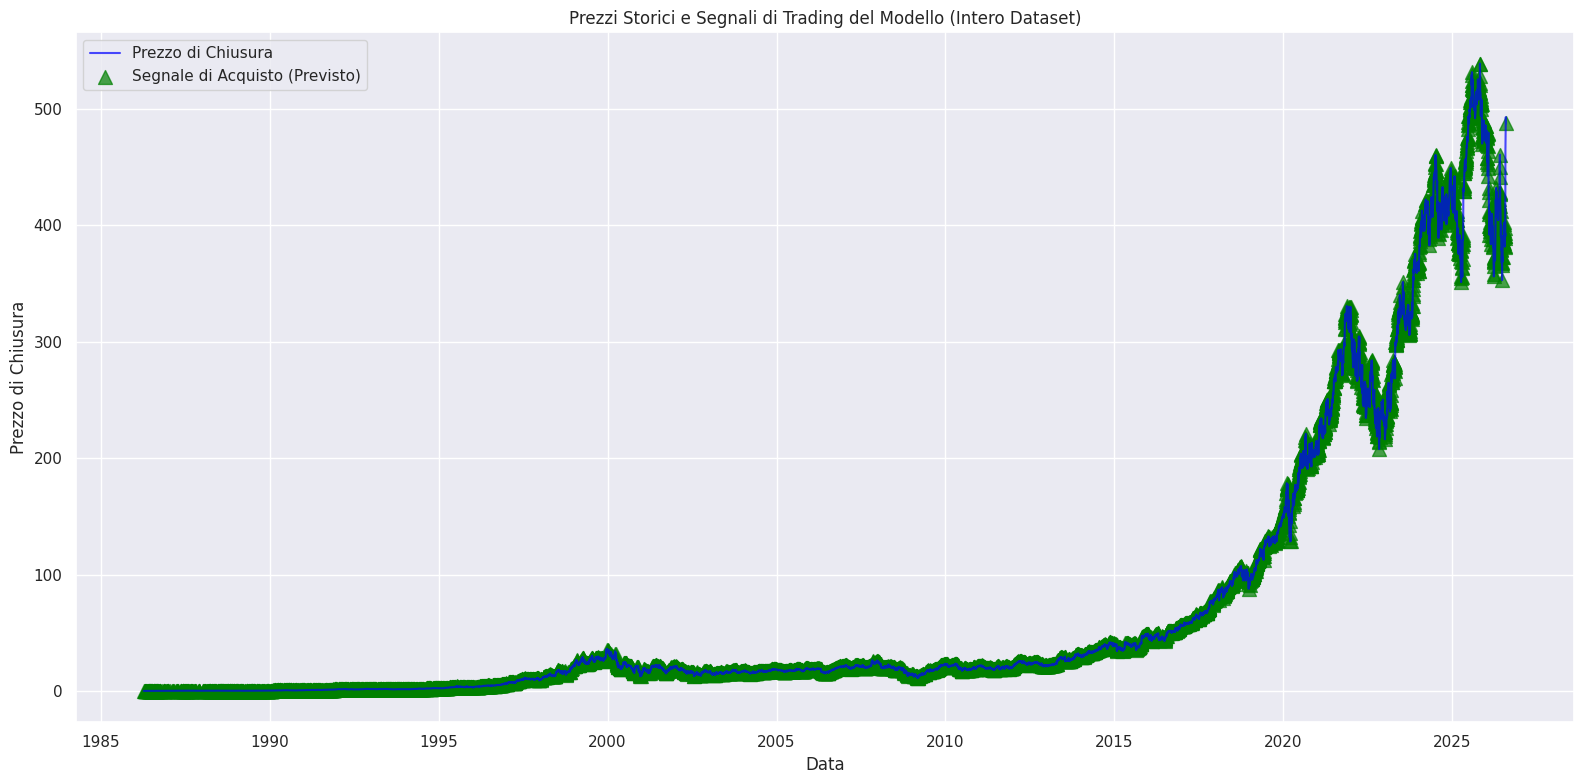

In [468]:
# Scaliamo l'intero set di feature X utilizzando lo StandardScaler dall'ultima iterazione.
X_scaled_full = ss.transform(X)

# Otteniamo le probabilità e le predizioni per l'intero dataset
y_proba_full = lr.predict_proba(X_scaled_full)[:, 1]
y_pred_full = lr.predict(X_scaled_full)

# Creiamo un DataFrame per la visualizzazione dei dati storici e dei segnali
df_history_signals = df_r.copy()
df_history_signals['Predicted_Signal'] = y_pred_full

plt.figure(figsize=(16, 8))
plt.plot(df_history_signals['Date'], df_history_signals['Close'], label='Prezzo di Chiusura', color='blue', alpha=0.7)

# Plottiamo i segnali di acquisto (dove Predicted_Signal è 1)
buy_signals_full = df_history_signals[df_history_signals['Predicted_Signal'] == 1]
plt.scatter(buy_signals_full['Date'], buy_signals_full['Close'], marker='^', color='green', s=100, label='Segnale di Acquisto (Previsto)', alpha=0.7)

plt.title('Prezzi Storici e Segnali di Trading del Modello (Intero Dataset)')
plt.xlabel('Data')
plt.ylabel('Prezzo di Chiusura')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##2. Visualizzazione dell’andamento delle feature più importanti

/tmp/ipykernel_670/1620532678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coeff.sort_values(by='Coefficient', ascending=False), palette='viridis')


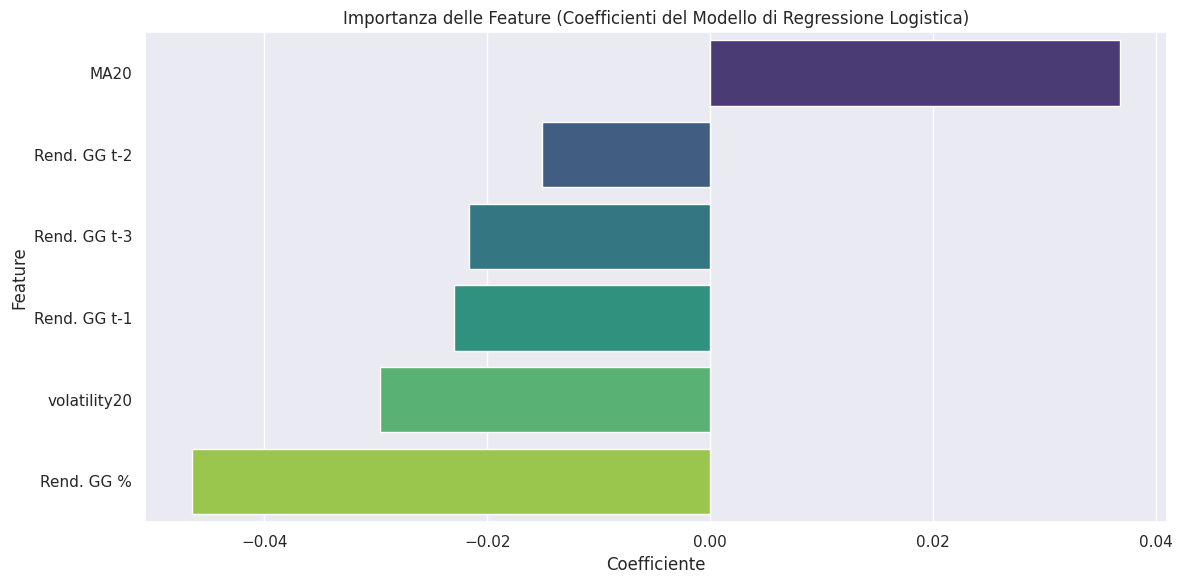

In [469]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=coeff.sort_values(by='Coefficient', ascending=False), palette='viridis')
plt.title('Importanza delle Feature (Coefficienti del Modello di Regressione Logistica)')
plt.xlabel('Coefficiente')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##3. Evidenziare la matrice di confusione e trend di performance.


--- Matrice di Confusione (Test Set) ---


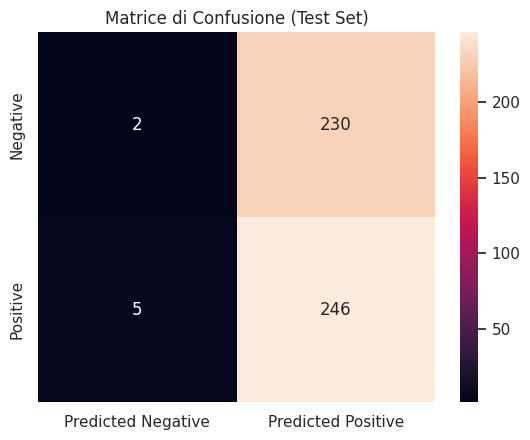


--- Trend di Performance: Learning Curve ---


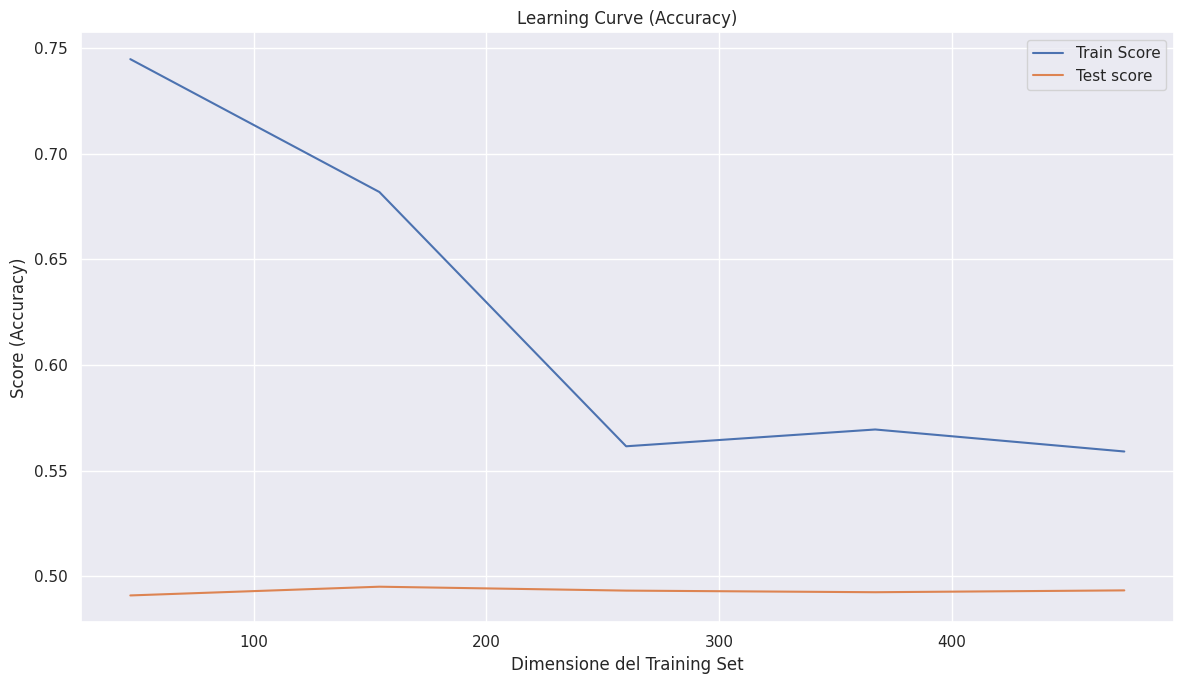


--- Trend delle Metriche di Performance per Ogni Split (Test Set) ---


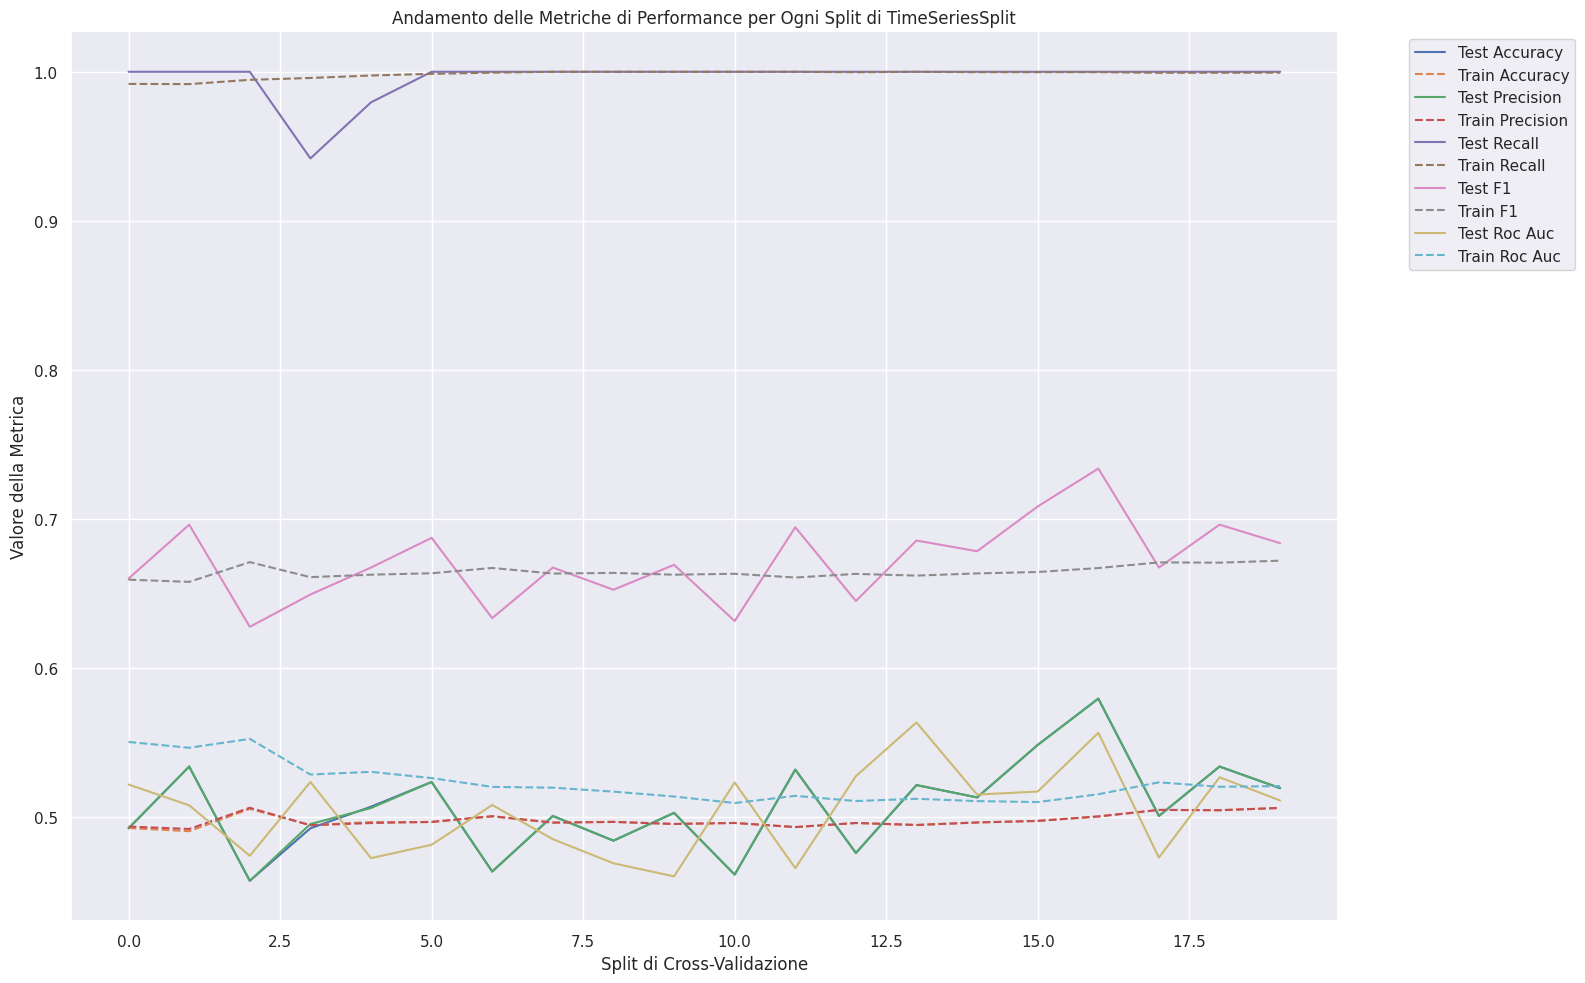

In [470]:
# Matrice di Confusione per il Test Set
print("\n--- Matrice di Confusione (Test Set) ---")
plot_confusion_matrix(Y_test, y_pred_test)
plt.title('Matrice di Confusione (Test Set)')
plt.show()

# Trend di Performance (Learning Curve) - per mostrare come le performance cambiano con più dati
print("\n--- Trend di Performance: Learning Curve ---")
plt.figure(figsize=(12, 7))
plt.plot(train_sizes_abs, train_sc.mean(axis=1), label="Train Score")
plt.plot(train_sizes_abs, test_sc.mean(axis=1), label="Test score")
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Dimensione del Training Set')
plt.ylabel('Score (Accuracy)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Trend delle Metriche di Performance per Ogni Split di TimeSeriesSplit
print("\n--- Trend delle Metriche di Performance per Ogni Split (Test Set) ---")
plt.figure(figsize=(16, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'Roc Auc']
for metric in metrics_to_plot:
    plt.plot(test_result.index, test_result[metric], label=f'Test {metric}')
    plt.plot(train_result.index, train_result[metric], linestyle='--', label=f'Train {metric}')

plt.title('Andamento delle Metriche di Performance per Ogni Split di TimeSeriesSplit')
plt.xlabel('Split di Cross-Validazione')
plt.ylabel('Valore della Metrica')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#9. Documentazione del Modello e del Processo



### 1. Scelte fatte in fase di Preprocessing e Feature Engineering

#### Preprocessing:
*   **Download Dati:** I dati storici di Microsoft (MSFT) sono stati scaricati da Yahoo Finance utilizzando `yfinance`.
*   **Pulizia Iniziale:** Il dataset è stato caricato da un file CSV, sono state rimosse le prime due righe di intestazione non necessarie, e le colonne 'Stock Splits' e 'Dividends' sono state eliminate in quanto non rilevanti per l'analisi corrente.
*   **Conversione Tipi:** La colonna 'Date' è stata convertita in formato datetime e le colonne relative ai prezzi e al volume ('Close', 'High', 'Low', 'Open', 'Volume') sono state convertite in tipo numerico (float).
*   **Gestione Valori Mancanti:** È stata eseguita una verifica per assicurare l'assenza di valori mancanti dopo la pulizia iniziale.
*   **Rimozione `NaN`:** Dopo la creazione delle feature, le righe con valori `NaN` residui (dovuti alle operazioni di `shift` e `rolling`) sono state rimosse per garantire un dataset pulito per l'addestramento del modello.

#### Feature Engineering:
*   **Rendimenti Giornalieri (`Rend. GG %`):** Calcolati come variazione percentuale giornaliera del prezzo di chiusura. Questa è una feature fondamentale per capire il movimento del mercato.
*   **Medie Mobili Semplici (`MA20`):** È stata calcolata la media mobile a 20 giorni sui prezzi di chiusura. Questa feature cattura le tendenze di medio termine del prezzo. Per evitare una perfetta collinearità con `MA5` e `MA10`, e data la maggiore correlazione di `MA20` con altre feature, sono state escluse `MA5` e `MA10` dal set di feature finali per il modello.
*   **Volatilità (`volatility20`):** Calcolata come deviazione standard annualizzata dei rendimenti giornalieri su una finestra di 20 giorni. Rappresenta il rischio del titolo.
*   **Lag Features (`Rend. GG t-1`, `Rend. GG t-2`, `Rend. GG t-3`):** Rendimenti giornalieri dei giorni precedenti (t-1, t-2, t-3). Queste feature introducono la memoria temporale nel modello, permettendo di considerare l'impatto dei movimenti passati sui movimenti futuri.
*   **Variabile Target (`Target`):** Definita come 1 se il prezzo di chiusura del giorno successivo è superiore al prezzo di chiusura corrente, 0 altrimenti. Questo trasforma il problema in una classificazione binaria: prevedere se il prezzo salirà o scenderà.

### 2. Limiti del Modello e Possibili Miglioramenti Futuri

#### Limiti Attuali del Modello:
*   **Configurazione del Modello:** Il modello di Regressione Logistica è stato configurato con regolarizzazione L1 (`penalty="l1"`) e il risolutore `saga`, insieme a una soglia di predizione di `0.4`. Questa soglia è stata scelta per bilanciare meglio precisione e recall, riducendo i falsi negativi e migliorando l'identificazione dei segnali di acquisto.
*   **Performance Moderate ma Migliorate:** Le metriche di performance (Accuracy, ROC AUC) sono ancora vicine allo 0.5, indicando una capacità predittiva complessiva limitata. Tuttavia, grazie alla soglia di 0.4, il modello ha mostrato un significativo miglioramento nella **Recall** (vicino a 1.0) e nell'**F1-score** (circa 0.67) sul test set, rispetto ai modelli precedenti. Questo suggerisce che il modello è ora più efficace nel rilevare i segnali positivi, anche se la **Precisione** rimane simile (circa 0.50), portando a un numero maggiore di falsi positivi.
*   **Bassa Correlazione delle Feature:** La matrice di correlazione ha mostrato correlazioni molto basse tra le feature selezionate (`MA20`, `volatility20`, `Rend. GG %`, `Rend. GG t-1`, `Rend. GG t-2`, `Rend. GG t-3`) e il target, suggerendo che le informazioni dirette fornite da queste feature potrebbero non essere predittive per i movimenti futuri del prezzo con questo modello.

#### Possibili Miglioramenti Futuri:
*   **Feature Engineering Avanzato:** Esplorare feature più complesse, come indicatori tecnici (RSI, MACD, Bande di Bollinger), analisi di sentiment da news o social media, o feature basate sull'analisi volumetrica. Si potrebbe considerare anche l'uso di tecniche di trasformazione delle feature per renderle più adatte al modello (es. trasformazioni non lineari).
*   **Modelli più Complessi:** Provare algoritmi di machine learning più robusti per serie temporali o problemi di classificazione, come: Random Forests, Gradient Boosting Machines (XGBoost, LightGBM), Support Vector Machines (SVM) o reti neurali ricorrenti (LSTM) che sono più adatte a catturare dipendenze temporali complesse.
*   **Integrazione di Dati ulteriori:** L'aggiunta di variabili macroeconomiche (tassi d'interesse, inflazione, PIL) o di altri asset correlati al titolo oggetto dell'analisi possono fornire un contesto più ampio e migliorare la capacità predittiva.

### 3. Come Interpretare i Risultati per gli Analisti

Il modello di Regressione Logistica sviluppato è un buon punto di partenz ma mostra performance limitate. Gli analisti di FinPearl dovrebbero interpretare i risultati con cautela, utilizzandoli come **strumento di supporto decisionale** piuttosto che come predittore definitivo. Ecco alcuni punti chiave per l'interpretazione:

*   **Segnali di Acquisto (`Predicted_Signal = 1`):** Il modello suggerisce una potenziale opportunità di acquisto. Tuttavia, data la bassa precisione, un segnale positivo non garantisce un movimento al rialzo. Questi segnali dovrebbero essere incrociati con altre analisi (fondamentali, tecniche, di sentiment).
*   **Probabilità di Confidenza (`Predicted_Probability`):** La probabilità associata a ogni previsione fornisce un'indicazione della confidenza del modello. Segnali con una probabilità vicina allo 0.5 (indicati come 'Bassa Confidenza' nelle visualizzazioni) dovrebbero essere trattati con maggiore scetticismo. Valori di probabilità più alti o più bassi indicano una maggiore 'certezza' del modello, ma sempre nei limiti delle sue capacità.
*   **Condizioni di Alta Volatilità (`High_Volatility`):** I periodi di alta volatilità sono stati identificati e visualizzati nel "Grafico dei prezzi di MSFT con relativi segnali di previsione, volatilità e bassa confidenza". Agire su segnali di acquisto durante questi periodi comporta un rischio maggiore. FinPearl potrebbe voler adottare una strategia più conservativa o addirittura evitare operazioni in queste fasi, indipendentemente dal segnale del modello.
*   **Matrice di Confusione:** La "Matrice di Confusione (Test Set)" è cruciale. L'elevato numero di Falsi Positivi (il modello prevede un rialzo ma il prezzo scende) e Falsi Negativi (il modello prevede un ribasso ma il prezzo sale) indica che il modello commette molti errori in entrambe le direzioni. Questo è un punto critico per gli analisti, in quanto i Falsi Negativi potrebbero far perdere opportunità, mentre i Falsi Positivi potrebbero portare a perdite.
*   **Learning Curve e Trend di Performance:** La "Learning Curve (Accuracy)" mostra che, anche con più dati di training, la performance sul test set non migliora significativamente, suggerendo che il modello potrebbe essere troppo semplice per il problema o che le feature non sono sufficientemente informative. L'"Andamento delle Metriche di Performance per Ogni Split di TimeSeriesSplit" evidenzia la variabilità delle prestazioni in diversi periodi di mercato, sottolineando la necessità di un monitoraggio continuo e di un adattamento delle strategie.
*   **Coefficienti delle Feature:** I "Coefficienti del Modello di Regressione Logistica" mostrano quali feature sono considerate più 'importanti' dal modello. Ad esempio, 'MA20' con un coefficiente positivo suggerisce una correlazione positiva con il target, mentre `Rend. GG %` con un coefficiente negativo suggerisce una correlazione negativa. Questo può aiutare a capire il 'ragionamento' del modello, anche se la causalità non è implicita.

In sintesi, il modello può servire come un filtro iniziale per identificare potenziali movimenti di prezzo, ma ogni segnale deve essere valutato attentamente in combinazione con l'analisi di rischio (volatilità, confidenza) e le metodologie di analisi tradizionali di FinPearl. Ulteriori sviluppi sono fortemente raccomandati per migliorare l'affidabilità e la robustezza delle previsioni.